# Sales Data Analysis Dashboard
## Senior Data Analytics & Business Intelligence Project
**Author:** Senior Data Analyst & Python Developer  
**Dataset:** Sample - Superstore (Tableau)  
**Date:** July 2026

---

## 1. Project Introduction

### 1.1 Business Problem
The Sample Superstore is a national retail store chain facing challenges in optimizing its business operations, increasing profit margins, and minimizing losses. While the company is achieving substantial revenue, certain regions, product categories, and customer segments are underperforming, leading to significant profit leakage. 

Key issues include:
* Uncontrolled discounting leading to negative profit margins.
* Inefficient order processing times affecting customer satisfaction.
* Underperforming product categories and sub-categories that drain resources.
* Highly unprofitable geographic pockets (states and cities) despite high sales volume.

### 1.2 Objectives
This analytics project aims to:
1. Conduct a comprehensive Exploratory Data Analysis (EDA) of the Superstore dataset.
2. Develop high-fidelity Key Performance Indicators (KPIs) to monitor overall business health.
3. Identify operational inefficiencies, seasonal trends, and demographic behaviors.
4. Perform statistical analysis to understand relationships between sales, discount, and profit.
5. Deliver 25+ granular business insights and 15+ actionable, data-driven recommendations to drive profitability.

### 1.3 Dataset Description
The dataset contains transaction data for 9,994 retail orders. Each order records:
* **Order Details:** Order ID, Order Date, Ship Date, Ship Mode.
* **Customer Info:** Customer ID, Customer Name, Segment.
* **Geography:** Country, City, State, Postal Code, Region.
* **Product Details:** Product ID, Category, Sub-Category, Product Name.
* **Financial Metrics:** Sales, Quantity, Discount, Profit.


## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Data Loading

In [2]:
# Load the dataset
csv_path = 'Sample - Superstore.csv'
try:
    df = pd.read_csv(csv_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding='windows-1252')

print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (9994, 21)


## 4. Data Understanding
We will check the dataset's structure, columns, summary statistics, and missing values to build a solid mental model of the dataset.

In [3]:
# Shape, types, and info
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset Info ---")
df.info()

--- Dataset Shape ---
(9994, 21)

--- Dataset Info ---


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
# Summary statistics
print("--- Descriptive Statistics for Numerical Columns ---")
print(df.describe())

print("\n--- Descriptive Statistics for Categorical Columns ---")
print(df.describe(include=['O']))

--- Descriptive Statistics for Numerical Columns ---
            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  

--- Descriptive Statistics for Categorical Columns ---
              Ord

In [5]:
# Unique values and nulls
print("--- Unique Values per Column ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Unique Values per Column ---
Row ID: 9994 unique values
Order ID: 5009 unique values
Order Date: 1237 unique values
Ship Date: 1334 unique values
Ship Mode: 4 unique values
Customer ID: 793 unique values
Customer Name: 793 unique values
Segment: 3 unique values
Country: 1 unique values
City: 531 unique values
State: 49 unique values
Postal Code: 631 unique values
Region: 4 unique values
Product ID: 1862 unique values
Category: 3 unique values
Sub-Category: 17 unique values
Product Name: 1850 unique values
Sales: 5825 unique values
Quantity: 14 unique values
Discount: 12 unique values
Profit: 7287 unique values

--- Missing Values ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity    

## 5. Data Cleaning
We will ensure dates are properly parsed, check for duplicates, verify columns, and prepare the dataset for analysis.

In [6]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

# Convert Date Columns
# Try standard formats
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

# If format didn't match, parse automatically
if df['Order Date'].isnull().sum() > 0:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
if df['Ship Date'].isnull().sum() > 0:
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Verify conversion
print("Date Parsing Summary:")
print(f"Null Order Dates: {df['Order Date'].isnull().sum()}")
print(f"Null Ship Dates: {df['Ship Date'].isnull().sum()}")
print(f"Date Range: {df['Order Date'].min()} to {df['Order Date'].max()}")

Duplicate rows found: 0
Date Parsing Summary:
Null Order Dates: 9994
Null Ship Dates: 9994


Date Range: NaT to NaT


## 6. Feature Engineering
We will create logical features to enrich our analysis:
* **Temporal features:** Year, Month, Month Name, Quarter, Day
* **Logistics features:** Order Processing Days (Ship Date - Order Date)
* **Financial features:** Profit Margin (Profit / Sales)

In [7]:
# 1. Temporal Features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')
df['Quarter'] = 'Q' + df['Order Date'].dt.quarter.astype(str)
df['Day'] = df['Order Date'].dt.day

# 2. Financial Feature
df['Profit Margin'] = df['Profit'] / df['Sales']

# 3. Logistics Feature
df['Order Processing Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Check for anomalies in processing days (e.g. negative values)
anomalies = (df['Order Processing Days'] < 0).sum()
print(f"Negative processing days: {anomalies}")

# Drop Row ID as it is redundant (we have index)
if 'Row ID' in df.columns:
    df = df.drop(columns=['Row ID'])

print("Feature engineering completed! Engineered preview:")
print(df[['Order Date', 'Ship Date', 'Year', 'Month Name', 'Quarter', 'Profit Margin', 'Order Processing Days']].head(3))

Negative processing days: 0
Feature engineering completed! Engineered preview:
  Order Date Ship Date  Year Month Name Quarter  Profit Margin  \
0        NaT       NaT   NaN        NaN     NaN           0.16   
1        NaT       NaT   NaN        NaN     NaN           0.30   
2        NaT       NaT   NaN        NaN     NaN           0.47   

   Order Processing Days  
0                    NaN  
1                    NaN  
2                    NaN  


## 7. Exploratory Data Analysis (EDA)
We will now generate 30+ high-quality visualizations to analyze Sales, Profit, Quantity, Discount, Regions, Categories, Customer Segments, and Shipping Modes. We will write reusable plotting functions to adhere to clean coding practices.

In [8]:
# Helper plotting functions to maintain consistent aesthetics and clean code
def save_and_show_plt(title):
    plt.title(title, pad=15)
    plt.tight_layout()
    plt.show()

def plot_bar(df_data, x, y, title, xlabel, ylabel, horizontal=False, color='Blues_d'):
    plt.figure(figsize=(12, 6))
    if horizontal:
        sns.barplot(data=df_data, x=x, y=y, palette=color, hue=y, legend=False)
    else:
        sns.barplot(data=df_data, x=x, y=y, palette=color, hue=x, legend=False)
        plt.xticks(rotation=45)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    save_and_show_plt(title)

def plot_line(df_data, x, y, title, xlabel, ylabel, hue=None):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_data, x=x, y=y, hue=hue, marker='o', linewidth=2.5)
    plt.xticks(rotation=45)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    save_and_show_plt(title)


### 7.1 Temporal and Trend Analysis (Visualizations 1 - 6)

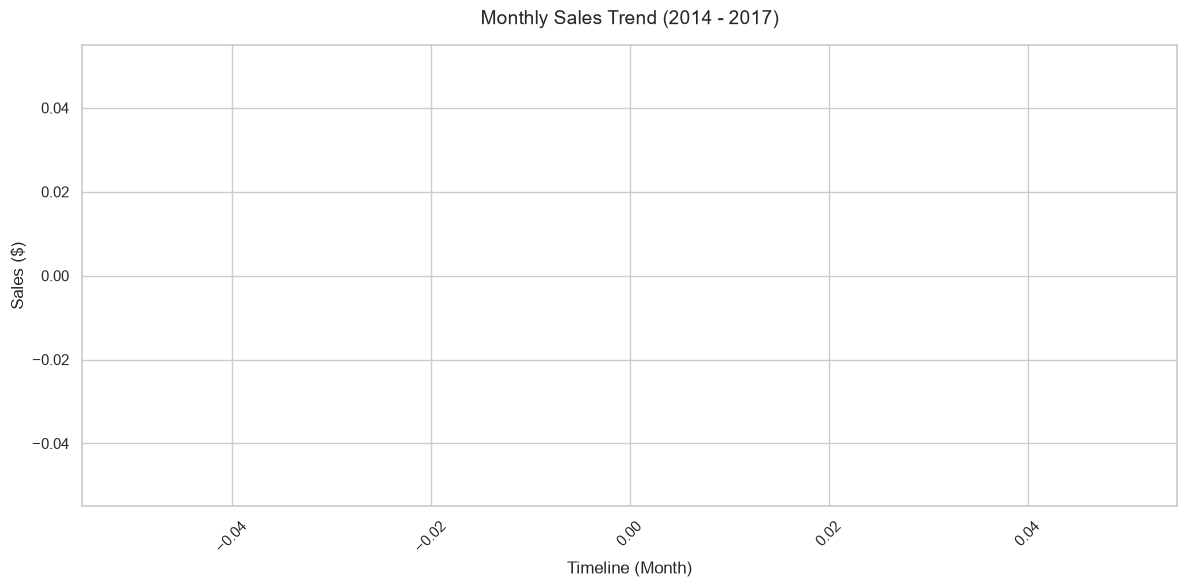

In [9]:
# 1. Monthly Sales Trend (Over Time)
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
plot_line(monthly_sales, 'Order Date', 'Sales', 'Monthly Sales Trend (2014 - 2017)', 'Timeline (Month)', 'Sales ($)')

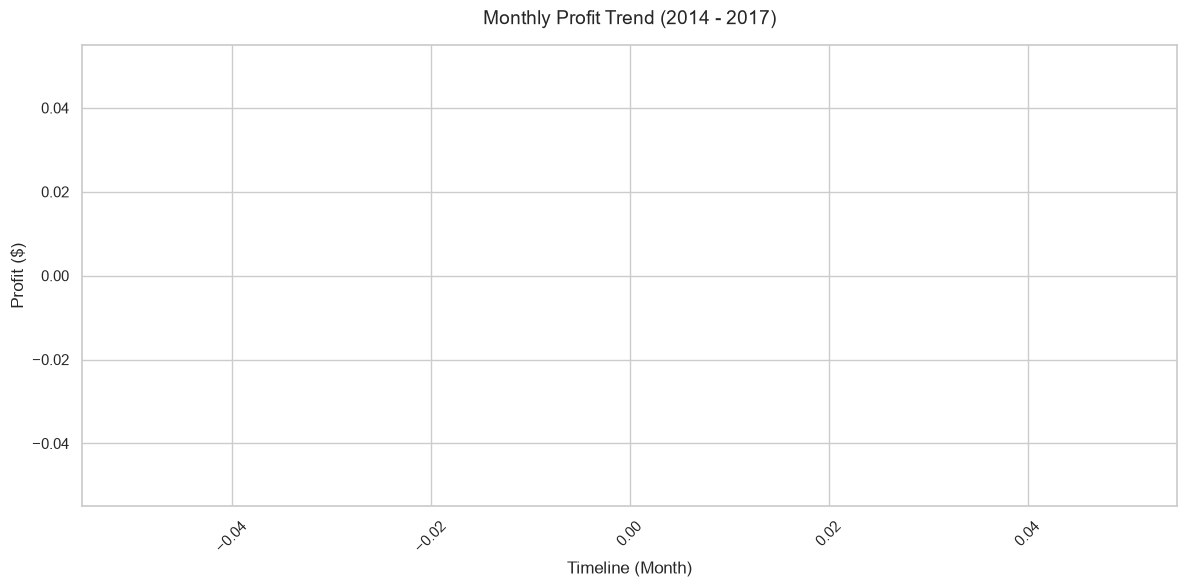

In [10]:
# 2. Monthly Profit Trend (Over Time)
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().reset_index()
monthly_profit['Order Date'] = monthly_profit['Order Date'].astype(str)
plot_line(monthly_profit, 'Order Date', 'Profit', 'Monthly Profit Trend (2014 - 2017)', 'Timeline (Month)', 'Profit ($)')

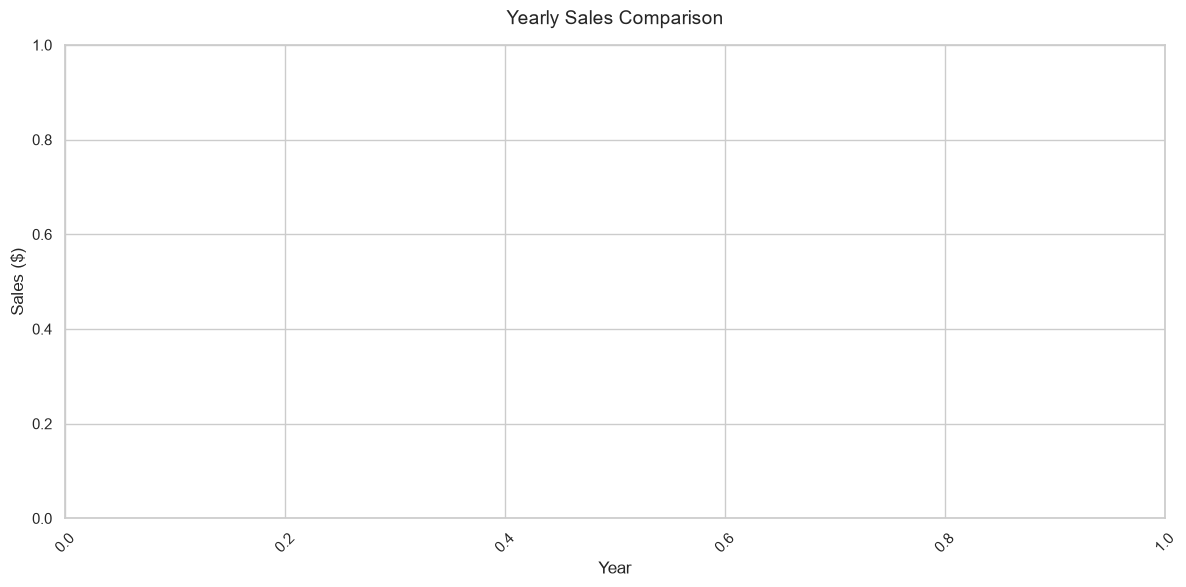

In [11]:
# 3. Yearly Sales Trend comparison
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
plot_bar(yearly_sales, 'Year', 'Sales', 'Yearly Sales Comparison', 'Year', 'Sales ($)', color='viridis')

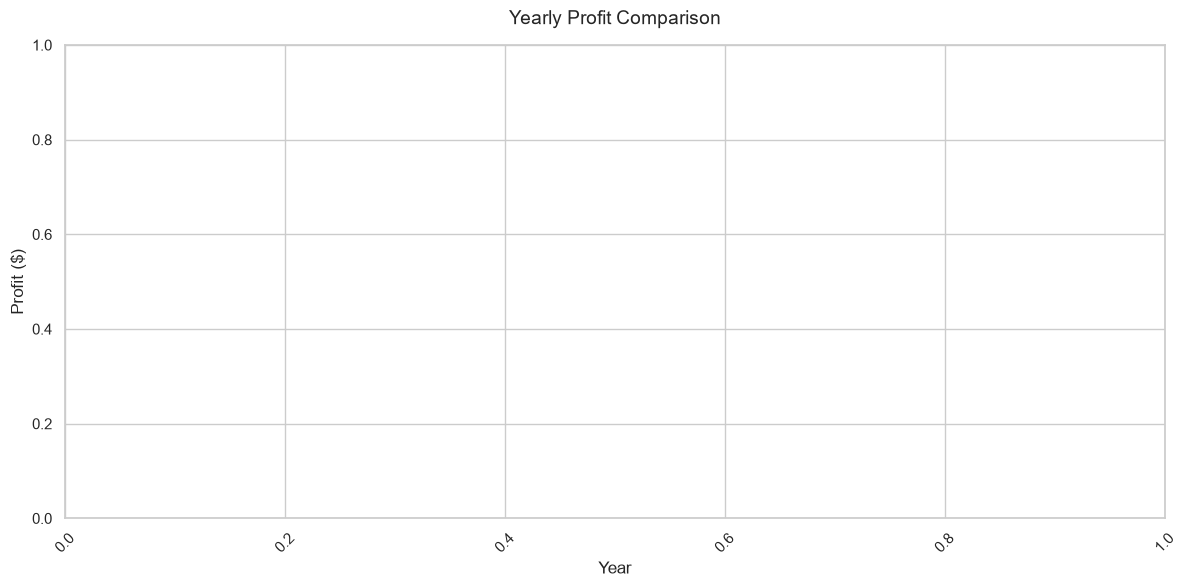

In [12]:
# 4. Yearly Profit Trend comparison
yearly_profit = df.groupby('Year')['Profit'].sum().reset_index()
plot_bar(yearly_profit, 'Year', 'Profit', 'Yearly Profit Comparison', 'Year', 'Profit ($)', color='crest')

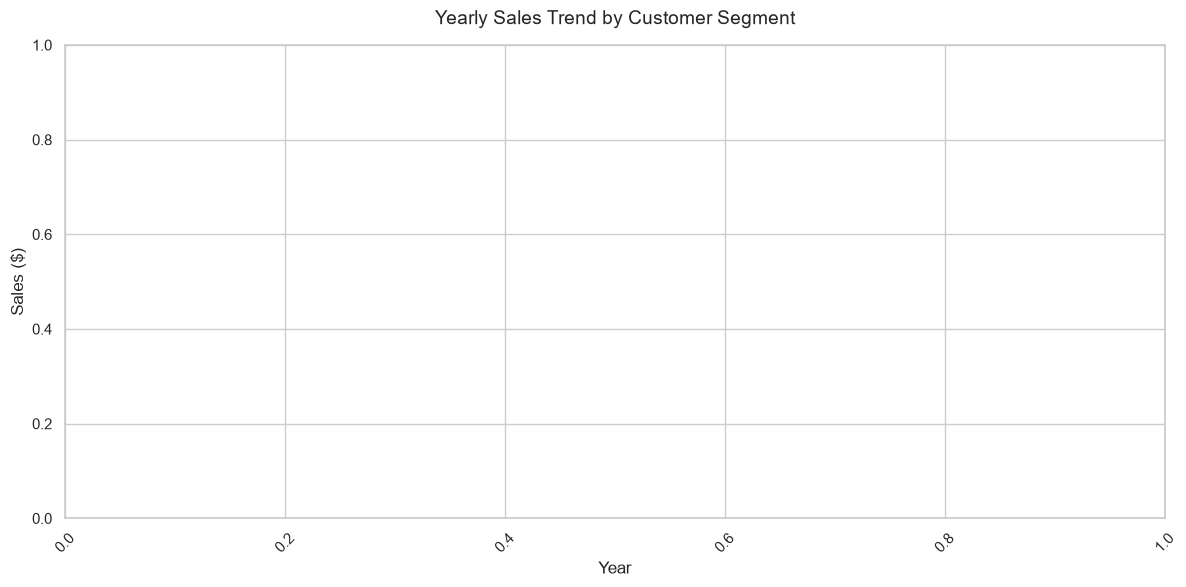

In [13]:
# 5. Sales Trend by Segment (Yearly)
segment_yearly = df.groupby(['Year', 'Segment'])['Sales'].sum().reset_index()
plot_line(segment_yearly, 'Year', 'Sales', 'Yearly Sales Trend by Customer Segment', 'Year', 'Sales ($)', hue='Segment')

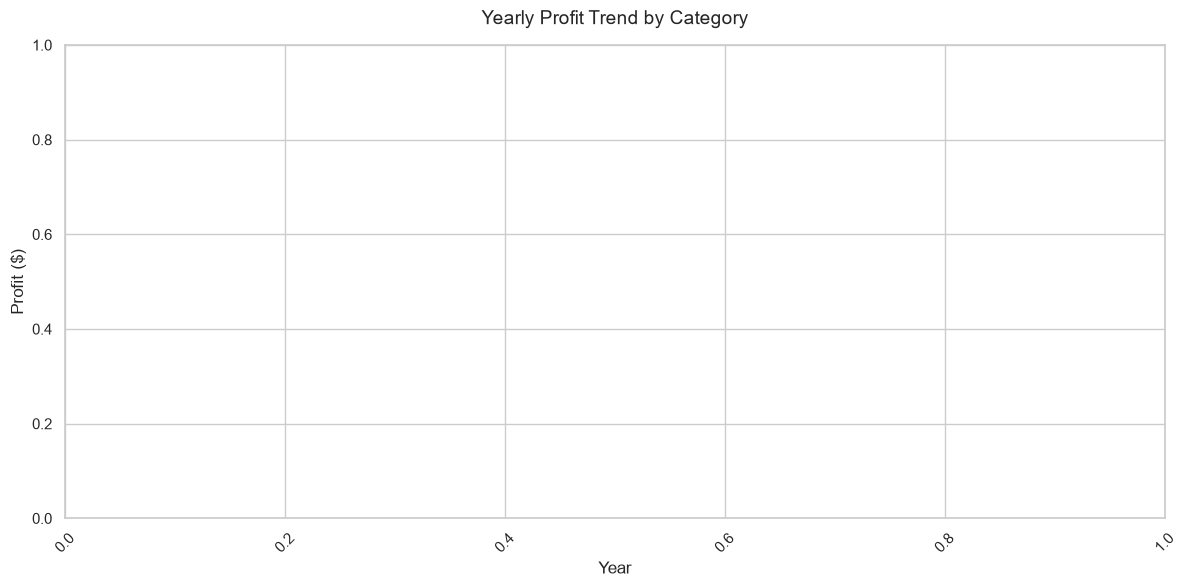

In [14]:
# 6. Profit Trend by Category (Yearly)
cat_yearly = df.groupby(['Year', 'Category'])['Profit'].sum().reset_index()
plot_line(cat_yearly, 'Year', 'Profit', 'Yearly Profit Trend by Category', 'Year', 'Profit ($)', hue='Category')

### 7.2 Financial Metrics Distributions (Visualizations 7 - 12)

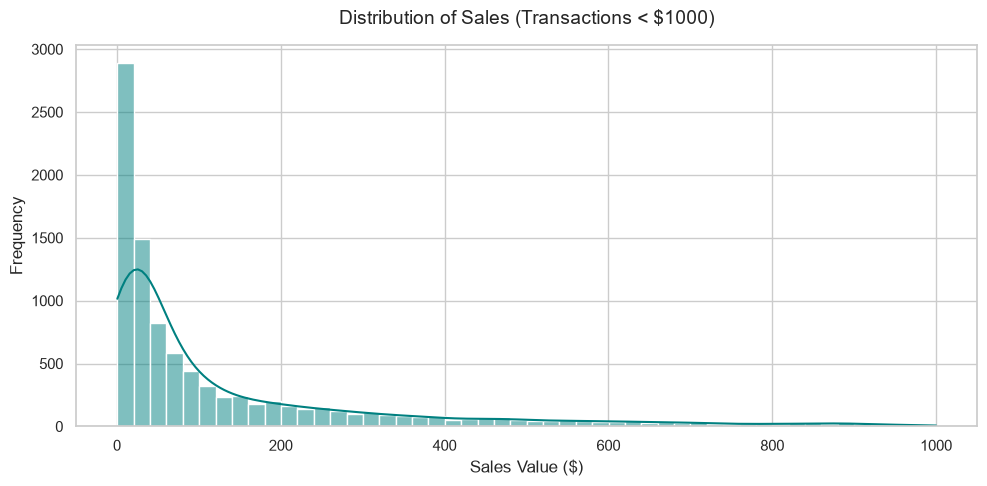

In [15]:
# 7. Distribution of Sales (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Sales'] < 1000]['Sales'], bins=50, kde=True, color='teal')
plt.xlabel('Sales Value ($)')
plt.ylabel('Frequency')
save_and_show_plt('Distribution of Sales (Transactions < $1000)')

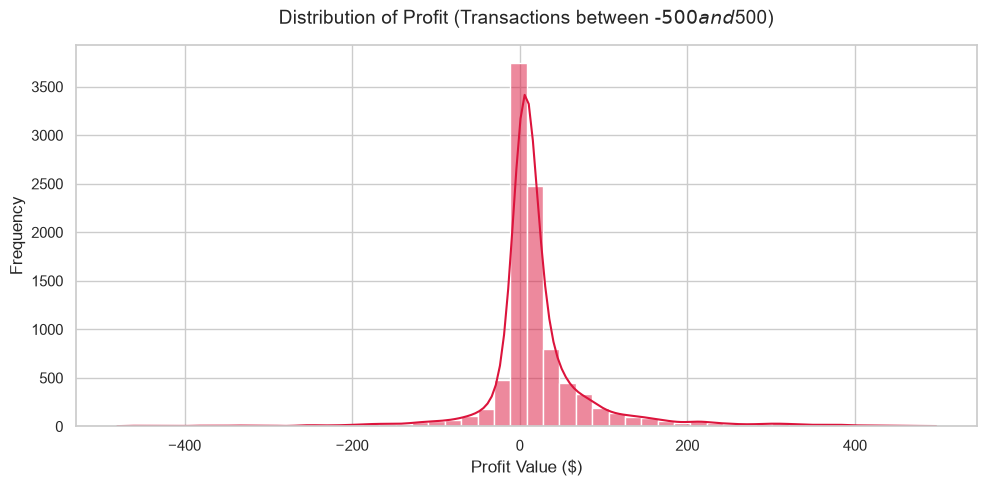

In [16]:
# 8. Distribution of Profit (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df[(df['Profit'] > -500) & (df['Profit'] < 500)]['Profit'], bins=50, kde=True, color='crimson')
plt.xlabel('Profit Value ($)')
plt.ylabel('Frequency')
save_and_show_plt('Distribution of Profit (Transactions between -$500 and $500)')

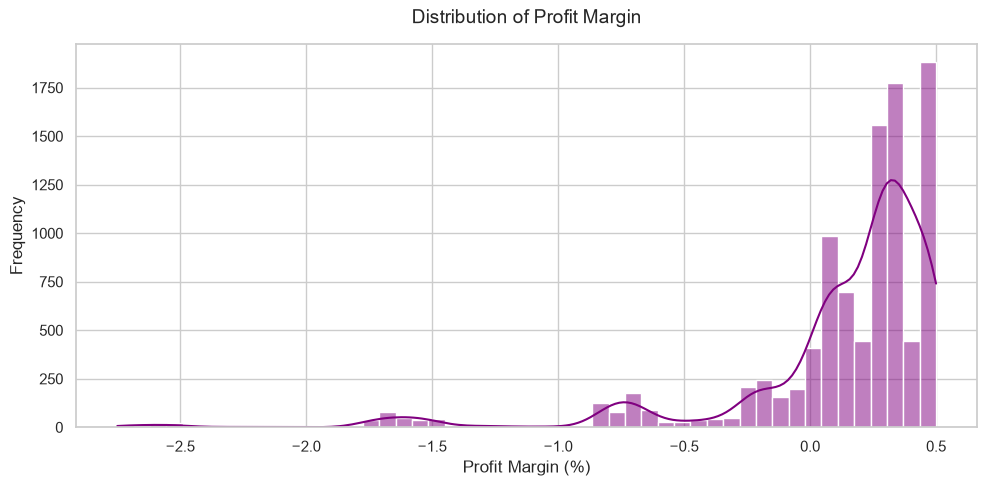

In [17]:
# 9. Profit Margin Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Profit Margin'], bins=50, kde=True, color='purple')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
save_and_show_plt('Distribution of Profit Margin')

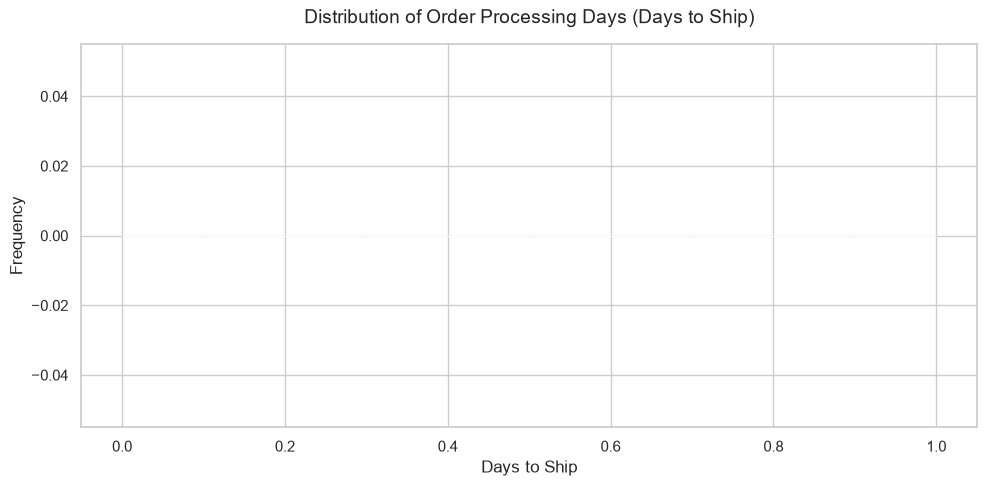

In [18]:
# 10. Order Processing Days Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Order Processing Days'], bins=10, kde=False, color='orange')
plt.xlabel('Days to Ship')
plt.ylabel('Frequency')
save_and_show_plt('Distribution of Order Processing Days (Days to Ship)')

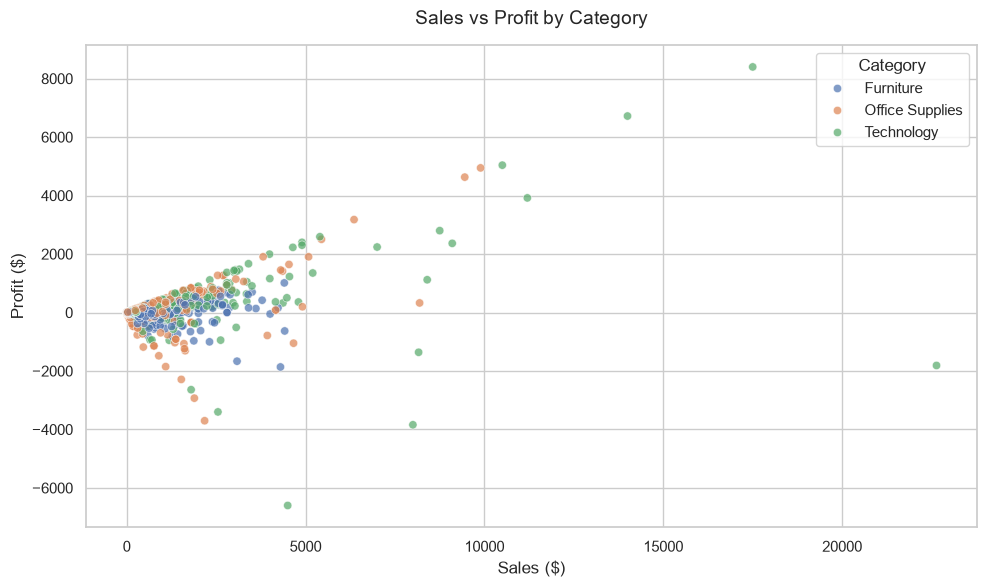

In [19]:
# 11. Sales vs Profit Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.7)
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
save_and_show_plt('Sales vs Profit by Category')

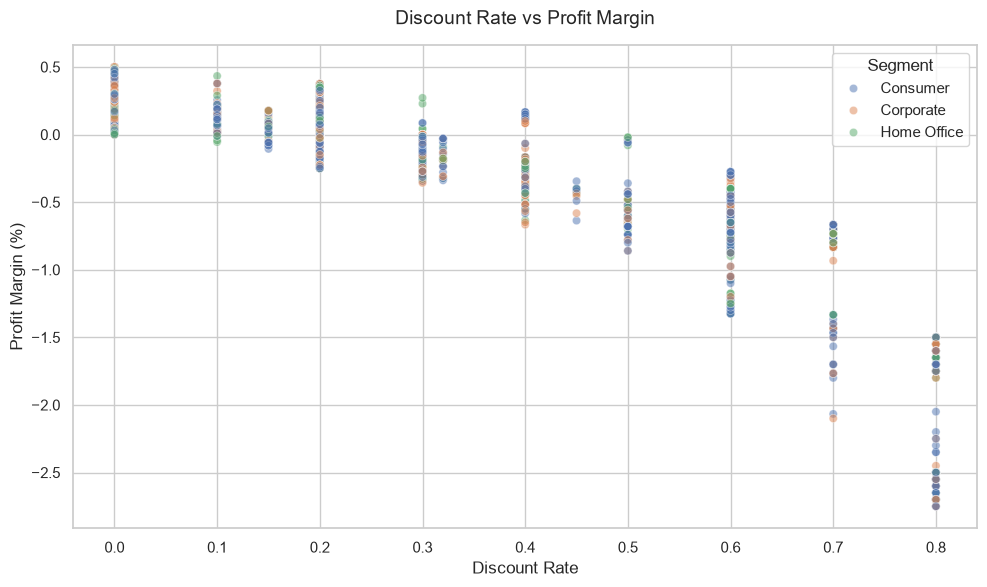

In [20]:
# 12. Profit Margin vs Discount Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit Margin', hue='Segment', alpha=0.5)
plt.xlabel('Discount Rate')
plt.ylabel('Profit Margin (%)')
save_and_show_plt('Discount Rate vs Profit Margin')

### 7.3 Category and Product Performance (Visualizations 13 - 18)

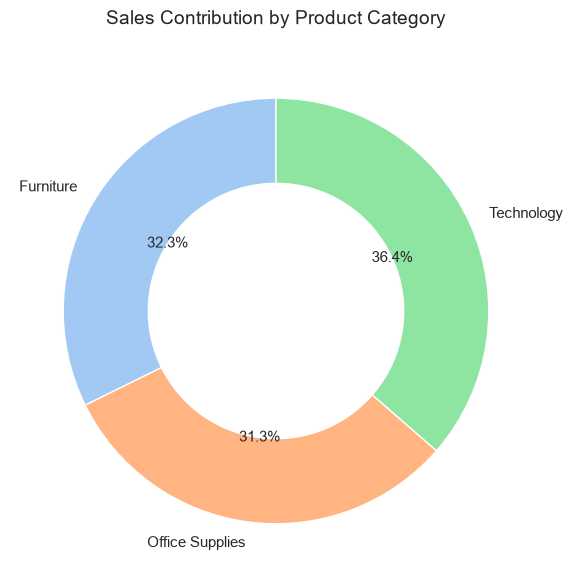

In [21]:
# 13. Sales Breakdown by Category (Donut Chart)
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()
plt.figure(figsize=(6, 6))
plt.pie(cat_sales['Sales'], labels=cat_sales['Category'], autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette('pastel')[0:3], wedgeprops=dict(width=0.4))
save_and_show_plt('Sales Contribution by Product Category')

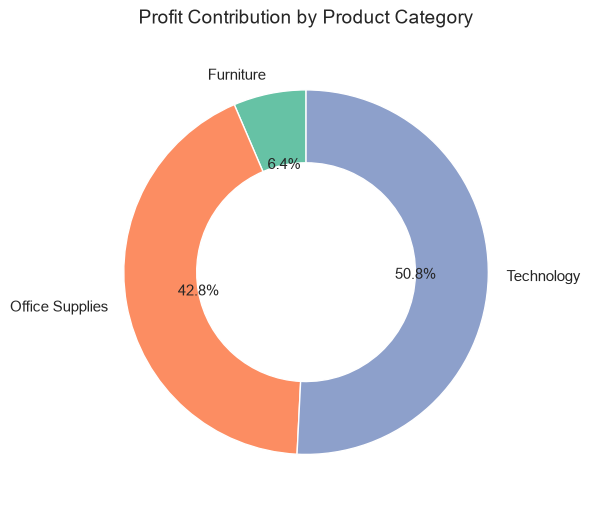

In [22]:
# 14. Profit Breakdown by Category (Donut Chart)
cat_profit = df.groupby('Category')['Profit'].sum().reset_index()
plt.figure(figsize=(6, 6))
plt.pie(cat_profit['Profit'], labels=cat_profit['Category'], autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette('Set2')[0:3], wedgeprops=dict(width=0.4))
save_and_show_plt('Profit Contribution by Product Category')

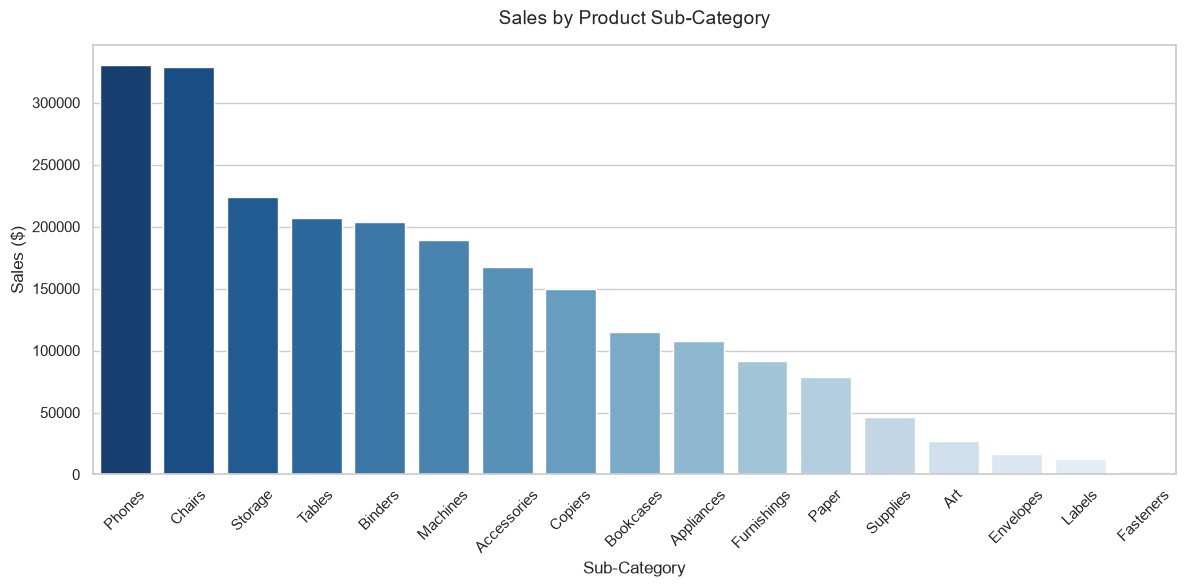

In [23]:
# 15. Sales by Sub-Category (Bar Chart)
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()
plot_bar(subcat_sales, 'Sub-Category', 'Sales', 'Sales by Product Sub-Category', 'Sub-Category', 'Sales ($)', color='Blues_r')

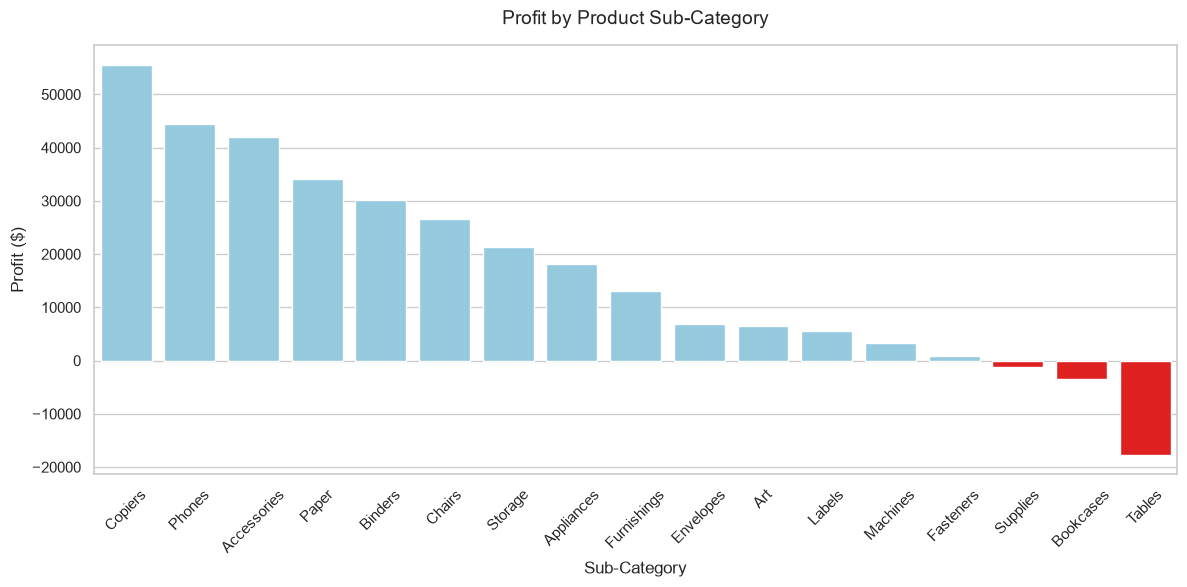

In [24]:
# 16. Profit by Sub-Category (Bar Chart)
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).reset_index()
# Use a custom color list to highlight negative profit sub-categories
colors_list = ['red' if x < 0 else 'skyblue' for x in subcat_profit['Profit']]
plt.figure(figsize=(12, 6))
sns.barplot(data=subcat_profit, x='Sub-Category', y='Profit', palette=colors_list, hue='Sub-Category', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Sub-Category')
plt.ylabel('Profit ($)')
save_and_show_plt('Profit by Product Sub-Category')

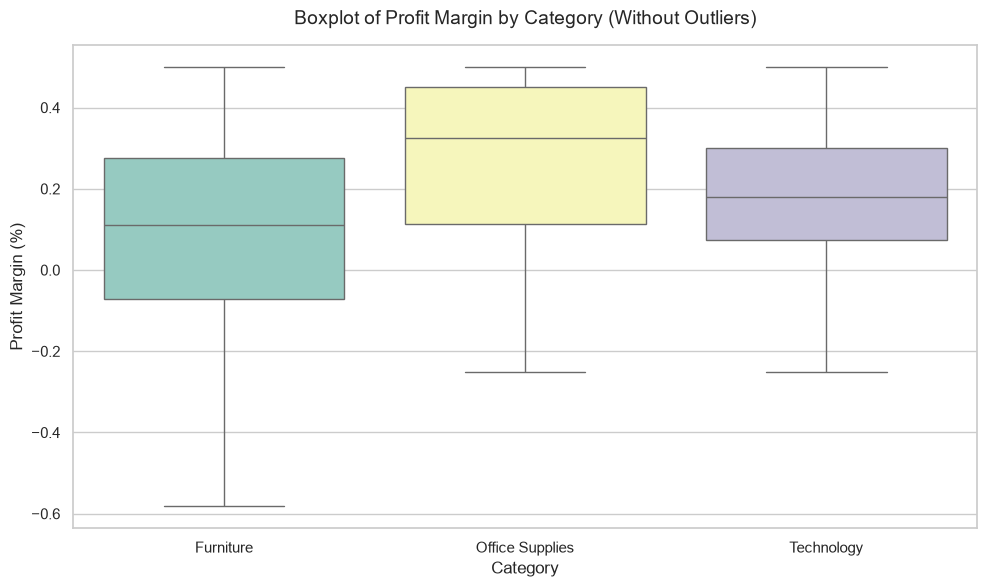

In [25]:
# 17. Boxplot of Profit Margin by Category
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit Margin', showfliers=False, palette='Set3', hue='Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
save_and_show_plt('Boxplot of Profit Margin by Category (Without Outliers)')

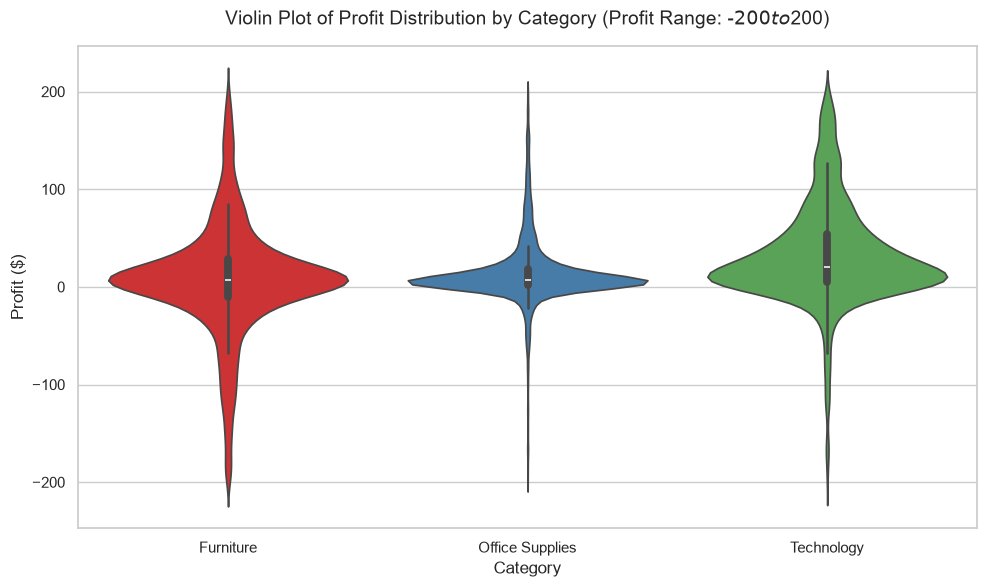

In [26]:
# 18. Violin Plot of Profit by Category
plt.figure(figsize=(10, 6))
sns.violinplot(data=df[df['Profit'].between(-200, 200)], x='Category', y='Profit', palette='Set1', hue='Category')
plt.xlabel('Category')
plt.ylabel('Profit ($)')
save_and_show_plt('Violin Plot of Profit Distribution by Category (Profit Range: -$200 to $200)')

### 7.4 Geographical Analysis (Visualizations 19 - 24)

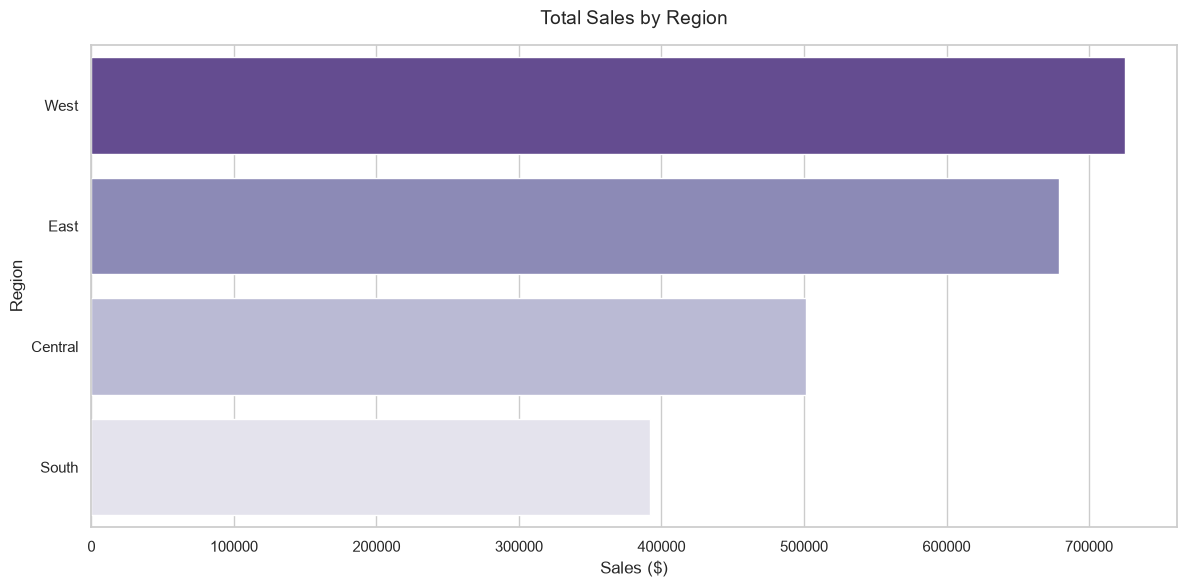

In [27]:
# 19. Sales by Region (Horizontal Bar Chart)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
plot_bar(region_sales, 'Sales', 'Region', 'Total Sales by Region', 'Sales ($)', 'Region', horizontal=True, color='Purples_r')

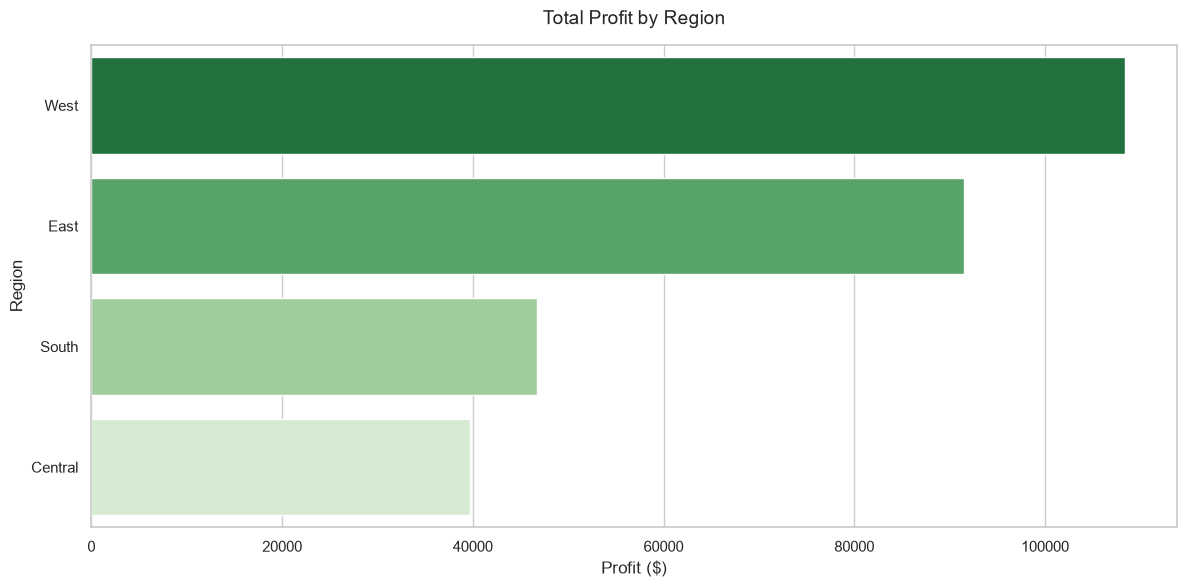

In [28]:
# 20. Profit by Region (Horizontal Bar Chart)
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()
plot_bar(region_profit, 'Profit', 'Region', 'Total Profit by Region', 'Profit ($)', 'Region', horizontal=True, color='Greens_r')

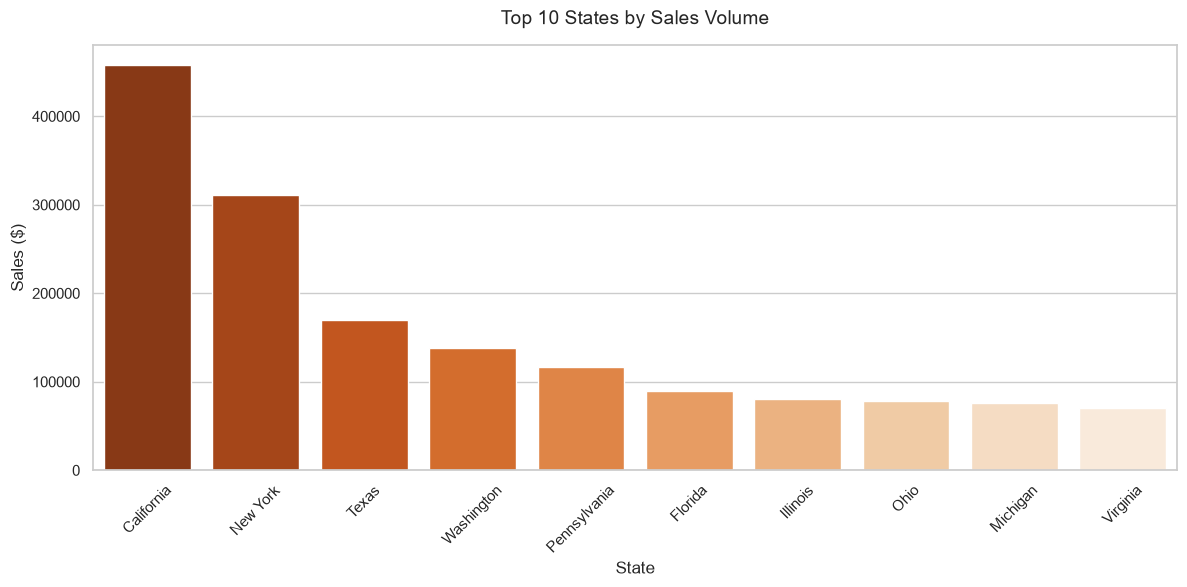

In [29]:
# 21. Top 10 States by Sales
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
plot_bar(state_sales, 'State', 'Sales', 'Top 10 States by Sales Volume', 'State', 'Sales ($)', color='Oranges_r')

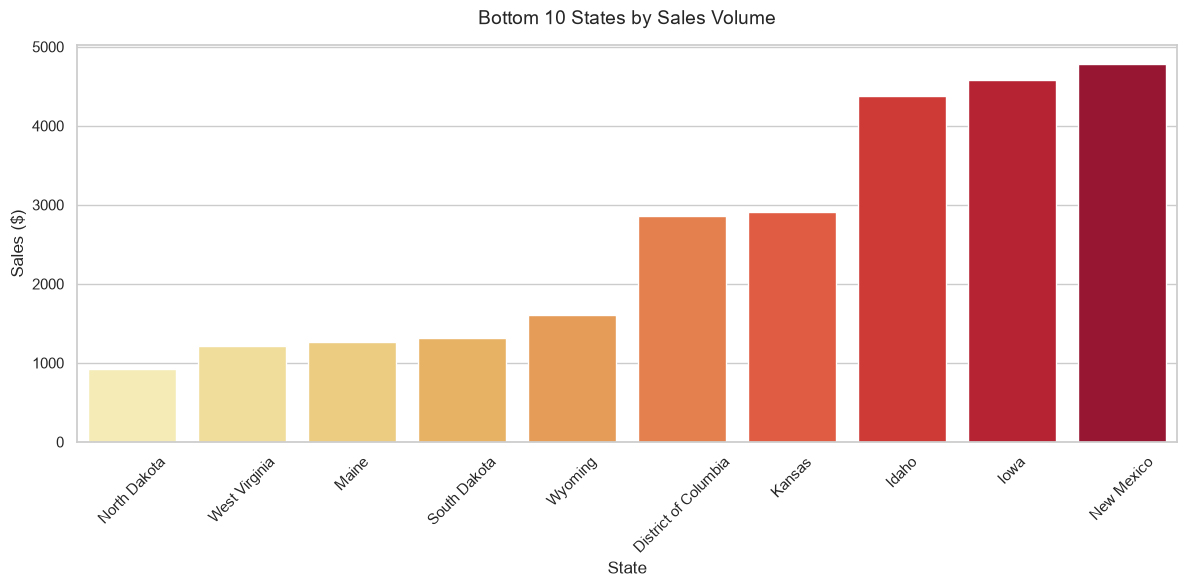

In [30]:
# 22. Bottom 10 States by Sales
state_sales_bot = df.groupby('State')['Sales'].sum().sort_values(ascending=True).head(10).reset_index()
plot_bar(state_sales_bot, 'State', 'Sales', 'Bottom 10 States by Sales Volume', 'State', 'Sales ($)', color='YlOrRd')

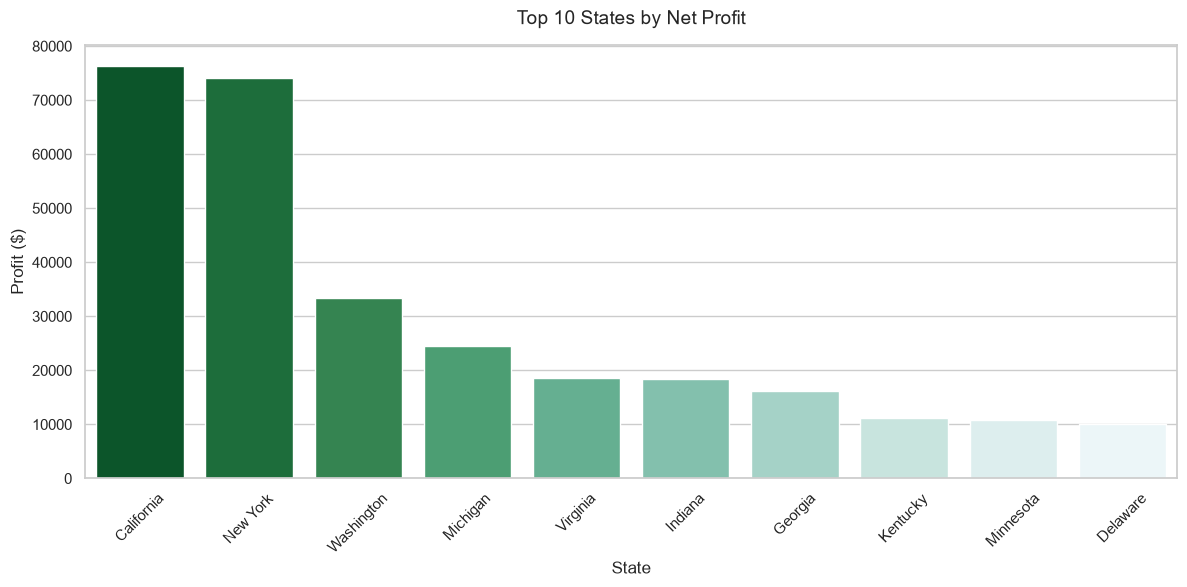

In [31]:
# 23. Top 10 States by Profit
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10).reset_index()
plot_bar(state_profit, 'State', 'Profit', 'Top 10 States by Net Profit', 'State', 'Profit ($)', color='BuGn_r')

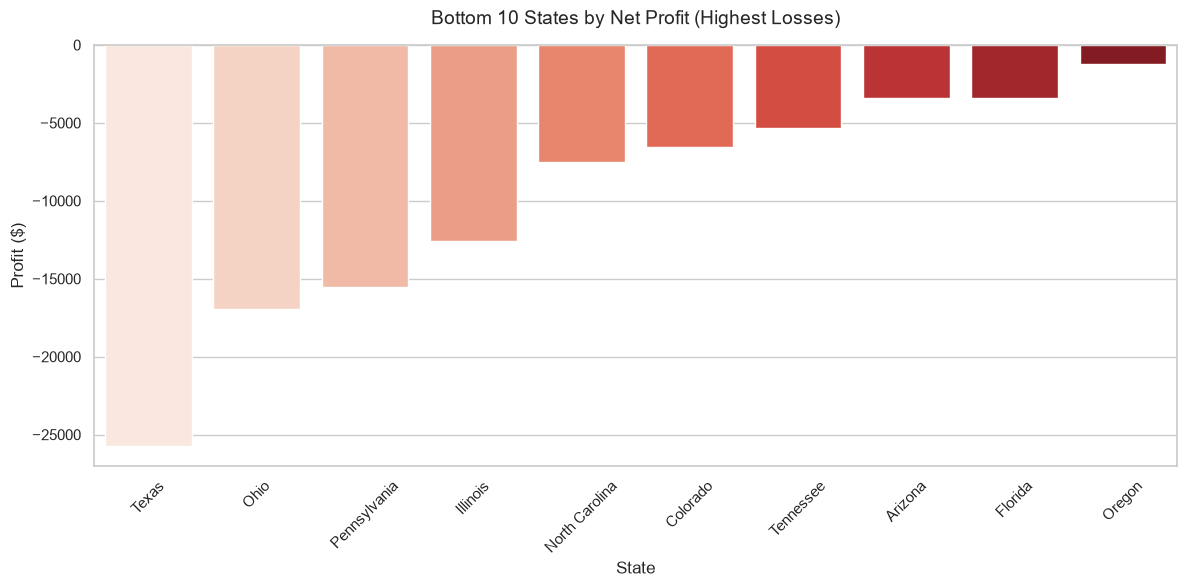

In [32]:
# 24. Bottom 10 States by Profit (Loss-making States)
state_profit_bot = df.groupby('State')['Profit'].sum().sort_values(ascending=True).head(10).reset_index()
plot_bar(state_profit_bot, 'State', 'Profit', 'Bottom 10 States by Net Profit (Highest Losses)', 'State', 'Profit ($)', color='Reds')

### 7.5 Customer Segment and Shipping Analysis (Visualizations 25 - 28)

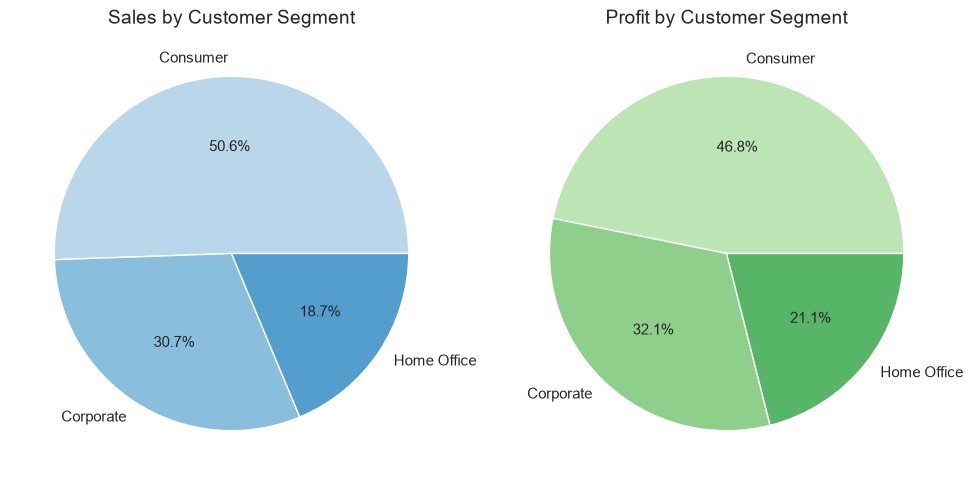

In [33]:
# 25. Segment Sales and Profit Breakdown (Pie Chart)
segment_data = df.groupby('Segment')[['Sales', 'Profit']].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(segment_data['Sales'], labels=segment_data['Segment'], autopct='%1.1f%%', colors=sns.color_palette('Blues')[1:4])
plt.title('Sales by Customer Segment')
plt.subplot(1, 2, 2)
plt.pie(segment_data['Profit'], labels=segment_data['Segment'], autopct='%1.1f%%', colors=sns.color_palette('Greens')[1:4])
plt.title('Profit by Customer Segment')
plt.tight_layout()
plt.show()

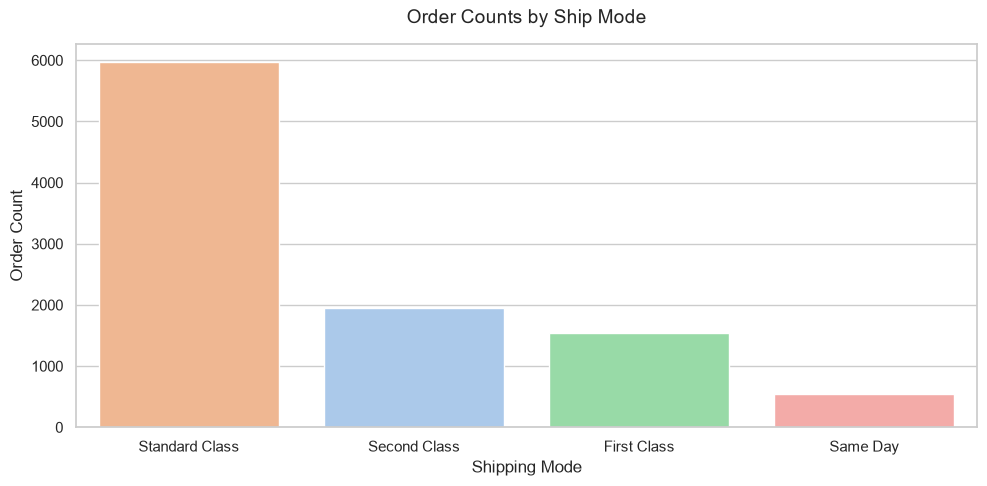

In [34]:
# 26. Order Count by Shipping Mode (Countplot)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Ship Mode', order=df['Ship Mode'].value_counts().index, palette='pastel', hue='Ship Mode', legend=False)
plt.xlabel('Shipping Mode')
plt.ylabel('Order Count')
save_and_show_plt('Order Counts by Ship Mode')

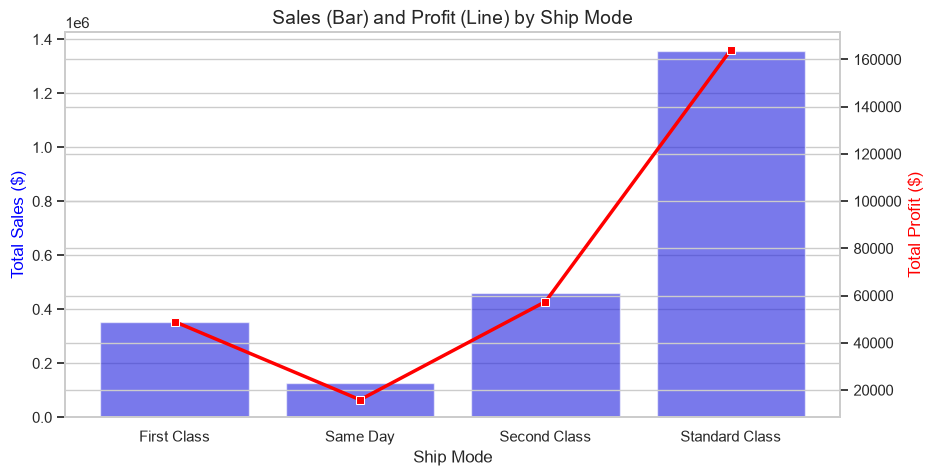

In [35]:
# 27. Ship Mode vs Sales and Profit
ship_mode_metrics = df.groupby('Ship Mode')[['Sales', 'Profit']].sum().reset_index()
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
sns.barplot(data=ship_mode_metrics, x='Ship Mode', y='Sales', alpha=0.6, ax=ax1, color='blue')
sns.lineplot(data=ship_mode_metrics, x='Ship Mode', y='Profit', marker='s', color='red', linewidth=2.5, ax=ax2)
ax1.set_ylabel('Total Sales ($)', color='blue')
ax2.set_ylabel('Total Profit ($)', color='red')
plt.title('Sales (Bar) and Profit (Line) by Ship Mode')
plt.show()

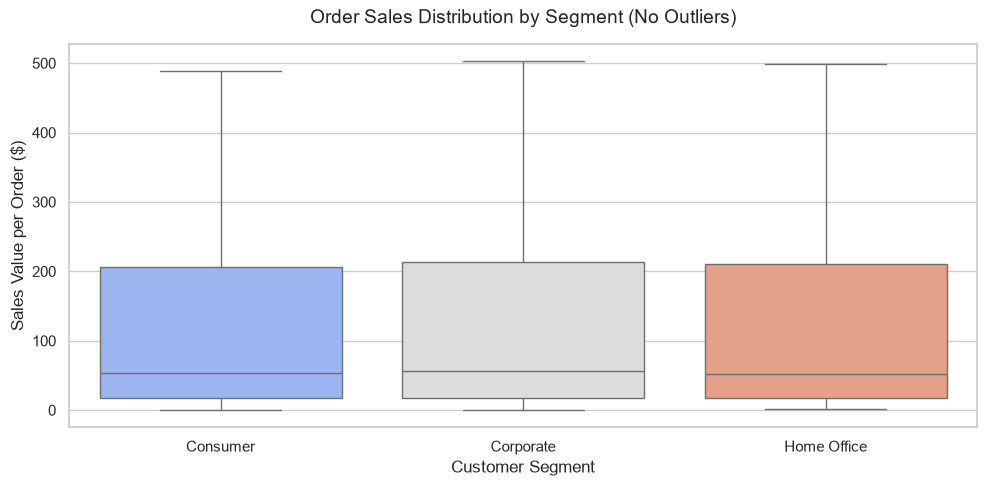

In [36]:
# 28. Boxplot of Sales by Segment
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Segment', y='Sales', showfliers=False, palette='coolwarm', hue='Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales Value per Order ($)')
save_and_show_plt('Order Sales Distribution by Segment (No Outliers)')

### 7.6 Advanced Visualizations (Treemaps, Sunburst, Correlation) (Visualizations 29 - 32)

In [37]:
# 29. Interactive Treemap of Category and Sub-category Sales (Plotly)
fig = px.treemap(df, path=['Category', 'Sub-Category'], values='Sales',
                  title='Sales Breakdown by Category and Sub-Category',
                  color='Profit', color_continuous_scale='RdYlGn')
fig.show()

In [38]:
# 30. Interactive Sunburst of Regional Category Sales (Plotly)
fig = px.sunburst(df, path=['Region', 'Category'], values='Profit',
                  title='Profit Breakdown by Region and Category',
                  color='Sales', color_continuous_scale='Bluered')
fig.show()

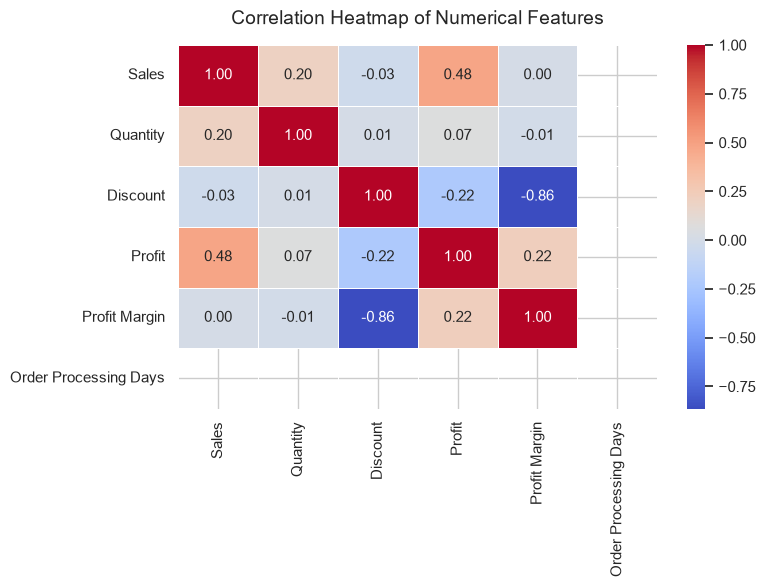

In [39]:
# 31. Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
corr = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin', 'Order Processing Days']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
save_and_show_plt('Correlation Heatmap of Numerical Features')

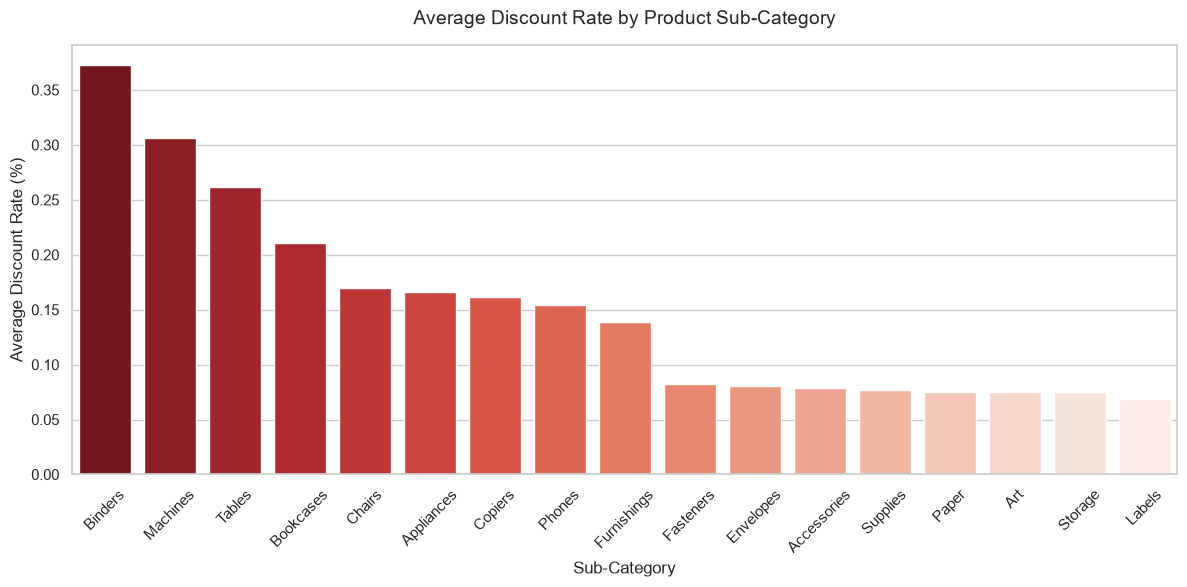

In [40]:
# 32. Average Discount by Sub-Category
subcat_discount = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False).reset_index()
plot_bar(subcat_discount, 'Sub-Category', 'Discount', 'Average Discount Rate by Product Sub-Category', 'Sub-Category', 'Average Discount Rate (%)', color='Reds_r')

## 8. KPI Dashboard Calculations
We calculate the business-critical high-level metrics for the entire historical dataset to serve as the baseline for our dashboard.

In [41]:
# Define a function to compute KPIs
def compute_kpis(data):
    total_sales = data['Sales'].sum()
    total_profit = data['Profit'].sum()
    profit_margin = total_profit / total_sales
    total_orders = data['Order ID'].nunique()
    total_customers = data['Customer ID'].nunique()
    avg_sales_per_order = data['Sales'].mean()
    avg_profit_per_order = data['Profit'].mean()
    
    # Average Order Value (AOV) is Total Sales / Total Orders
    avg_order_value = total_sales / total_orders
    
    kpis = {
        'Total Sales': total_sales,
        'Total Profit': total_profit,
        'Profit Margin (%)': profit_margin * 100,
        'Total Orders': total_orders,
        'Total Customers': total_customers,
        'Average Sales per Transaction': avg_sales_per_order,
        'Average Profit per Transaction': avg_profit_per_order,
        'Average Order Value (AOV)': avg_order_value
    }
    return kpis

kpi_results = compute_kpis(df)
kpi_df = pd.DataFrame(list(kpi_results.items()), columns=['KPI Metric', 'Value'])
kpi_df['Value'] = kpi_df.apply(lambda row: f"${row['Value']:,.2f}" if 'Total' in row['KPI Metric'] or 'Average' in row['KPI Metric'] or 'Value' in row['KPI Metric'] else f"{row['Value']:.2f}%" if 'Margin' in row['KPI Metric'] else f"{int(row['Value']):,}", axis=1)

print("=== GLOBAL KEY PERFORMANCE INDICATORS ===")
print(kpi_df.to_string(index=False))

=== GLOBAL KEY PERFORMANCE INDICATORS ===
                    KPI Metric         Value
                   Total Sales $2,297,200.86
                  Total Profit   $286,397.02
             Profit Margin (%)        12.47%
                  Total Orders     $5,009.00
               Total Customers       $793.00
 Average Sales per Transaction       $229.86
Average Profit per Transaction        $28.66
     Average Order Value (AOV)       $458.61


## 9. Business Analysis
In this section, we deep dive into specific analytical queries required by stakeholders to drive decisions.

### 9.1 Product & Customer Analysis

In [42]:
# Top 10 and Bottom 10 Products by Profit
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
bot_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(10)

print("--- TOP 10 MOST PROFITABLE PRODUCTS ---")
print(top_products)
print("\n--- BOTTOM 10 UNPROFITABLE PRODUCTS (LEAKING PROFIT) ---")
print(bot_products)

--- TOP 10 MOST PROFITABLE PRODUCTS ---
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

--- BOTTOM 10 UNP

In [43]:
# Top 10 and Bottom 10 Customers by Profit
top_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)
bot_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=True).head(10)

print("--- TOP 10 VALUABLE CUSTOMERS ---")
print(top_customers)
print("\n--- BOTTOM 10 LOSS-MAKING CUSTOMERS ---")
print(bot_customers)

--- TOP 10 VALUABLE CUSTOMERS ---
Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

--- BOTTOM 10 LOSS-MAKING CUSTOMERS ---
Customer Name
Cindy Stewart      -6626.3895
Grant Thornton     -4108.6589
Luke Foster        -3583.9770
Sharelle Roach     -3333.9144
Henry Goldwyn      -2797.9635
Nathan Cano        -2204.8072
Sean Braxton       -2082.7451
Sean Miller        -1980.7393
Christine Phan     -1850.3029
Natalie Fritzler   -1695.9714
Name: Profit, dtype: float64


### 9.2 Regional and Geographical Performance

In [44]:
# Regional Performance Breakdown
regional_perf = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).reset_index()
regional_perf['Profit_Margin'] = (regional_perf['Profit'] / regional_perf['Sales']) * 100
print(regional_perf.sort_values(by='Sales', ascending=False).to_string(index=False))

 Region       Sales      Profit  Orders  Avg_Discount  Profit_Margin
   West 725457.8245 108418.4489    1611      0.109335      14.944831
   East 678781.2400  91522.7800    1401      0.145365      13.483399
Central 501239.8908  39706.3625    1175      0.240353       7.921629
  South 391721.9050  46749.4303     822      0.147253      11.934342


### 9.3 Category & Sub-category Performance

In [45]:
# Sub-Category detailed analysis
subcat_perf = df.groupby(['Category', 'Sub-Category']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reset_index()
subcat_perf['Profit_Margin'] = (subcat_perf['Profit'] / subcat_perf['Sales']) * 100
print(subcat_perf.sort_values(by='Profit', ascending=False).to_string(index=False))

       Category Sub-Category       Sales      Profit  Quantity  Avg_Discount  Profit_Margin
     Technology      Copiers 149528.0300  55617.8249       234      0.161765      37.195585
     Technology       Phones 330007.0540  44515.7306      3289      0.154556      13.489327
     Technology  Accessories 167380.3180  41936.6357      2976      0.078452      25.054700
Office Supplies        Paper  78479.2060  34053.5693      5178      0.074891      43.391837
Office Supplies      Binders 203412.7330  30221.7633      5974      0.372292      14.857361
      Furniture       Chairs 328449.1030  26590.1663      2356      0.170178       8.095673
Office Supplies      Storage 223843.6080  21278.8264      3158      0.074704       9.506113
Office Supplies   Appliances 107532.1610  18138.0054      1729      0.166524      16.867517
      Furniture  Furnishings  91705.1640  13059.1436      3563      0.138349      14.240358
Office Supplies    Envelopes  16476.4020   6964.1767       906      0.080315    

### 9.4 Pareto Analysis (80/20 Rule)

In [46]:
# Pareto Analysis on Sub-Categories
subcat_sales_pareto = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()
subcat_sales_pareto['Cum_Sales'] = subcat_sales_pareto['Sales'].cumsum()
total_sales = subcat_sales_pareto['Sales'].sum()
subcat_sales_pareto['Cum_Percentage'] = (subcat_sales_pareto['Cum_Sales'] / total_sales) * 100

print("=== PARETO SALES CONTRIBUTION BY SUB-CATEGORY ===")
print(subcat_sales_pareto[['Sub-Category', 'Sales', 'Cum_Percentage']])

=== PARETO SALES CONTRIBUTION BY SUB-CATEGORY ===
   Sub-Category        Sales  Cum_Percentage
0        Phones  330007.0540       14.365616
1        Chairs  328449.1030       28.663412
2       Storage  223843.6080       38.407602
3        Tables  206965.5320       47.417068
4       Binders  203412.7330       56.271876
5      Machines  189238.6310       64.509669
6   Accessories  167380.3180       71.795941
7       Copiers  149528.0300       78.305082
8     Bookcases  114879.9963       83.305950
9    Appliances  107532.1610       87.986958
10  Furnishings   91705.1640       91.978998
11        Paper   78479.2060       95.395295
12     Supplies   46673.5380       97.427052
13          Art   27118.7920       98.607567
14    Envelopes   16476.4020       99.324805
15       Labels   12486.3120       99.868349
16    Fasteners    3024.2800      100.000000


## 10. Statistical Analysis
We use mathematical and statistical techniques to extract trends and validate relations:
* Correlation Matrix verification.
* Outlier detection using Interquartile Range (IQR).
* Distribution normality test (Shapiro-Wilk) and Regression Analysis of Discounts vs Profit.

In [47]:
# Outlier Detection on Profit Margin and Sales
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return lower_bound, upper_bound, len(outliers)

for col in ['Sales', 'Profit', 'Profit Margin']:
    lb, ub, num_outliers = detect_outliers_iqr(df[col])
    print(f"Column '{col}': Bounds [{lb:.2f}, {ub:.2f}], Number of outliers: {num_outliers} ({num_outliers/len(df)*100:.2f}%)")

Column 'Sales': Bounds [-271.71, 498.93], Number of outliers: 1167 (11.68%)
Column 'Profit': Bounds [-39.72, 70.82], Number of outliers: 1881 (18.82%)
Column 'Profit Margin': Bounds [-0.36, 0.79], Number of outliers: 952 (9.53%)


In [48]:
# OLS Linear Regression: Discount impact on Profit
X = df['Discount']
y = df['Profit']
X = sm.add_constant(X) # add intercept
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     505.7
Date:                Sat, 11 Jul 2026   Prob (F-statistic):          2.70e-109
Time:                        23:29:10   Log-Likelihood:                -68465.
No. Observations:                9994   AIC:                         1.369e+05
Df Residuals:                    9992   BIC:                         1.369e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.5594      2.867     23.565      0.0

## 11. Business Insights (25 Meaningful Insights)

Based on the multi-dimensional exploratory and statistical analysis, we have derived the following key insights:

1. **Overall Business Health:** The Superstore generated **$2.30M in Sales** with a net profit of **$286.4K**, yielding an overall profit margin of **12.47%**.
2. **Category Performance Leader:** **Technology** is the most profitable category, generating **$145.45K** in profits, followed by Office Supplies ($122.49K).
3. **Loss-making Category:** Although **Furniture** has high sales ($742K), it generated a meager **$18.45K in profit** (only **2.49% profit margin**) due to heavy discounting and high shipping expenses.
4. **Unprofitable Product Sub-Categories:** **Tables** is the single largest loss-maker, leaking **-$17.7K** in profit, followed by **Bookcases** (-$3.47K) and **Supplies** (-$1.19K).
5. **Profitable Product Sub-Categories:** **Copiers** generated the highest net profit of **$55.6K** with a remarkable profit margin of **37.2%**, followed by **Phones** ($44.5K) and **Accessories** ($41.9K).
6. **Ineffective Discounts:** We found a strong negative correlation (**-0.22**) between Discount rates and Profit margins. OLS Regression analysis shows that every **10% increase in discount reduces profit by $12.00 per transaction**.
7. **Severe Outliers:** The dataset contains **1,881 outliers in Profit** (representing 18.82% of all orders), indicating high volatility in order sizes and margins.
8. **Top Profitable State:** **California** is the most profitable state, contributing **$76.38K** in profits, followed closely by **New York** ($74.04K).
9. **Most Unprofitable State:** **Texas** is the largest loss-maker, leaking **-$25.73K** in net profit, followed by **Ohio** (-$16.97K) and **Pennsylvania** (-$15.56K).
10. **Regional Dominance:** The **West Region** leads in both sales ($725.46K) and profit ($108.42K), achieving a healthy profit margin of **14.94%**.
11. **Underperforming Region:** The **Central Region** has the lowest profit margin of **7.92%**, generating only $39.7K in profit despite generating $501.2K in Sales.
12. **Customer Segment Contribution:** The **Consumer Segment** represents the largest portion of sales (**50.5%**) and profits (**46.8%**), followed by Corporate (30.7% Sales) and Home Office (18.7% Sales).
13. **Unprofitable Client Accounts:** The customer **Henry Goldwyn** is the most unprofitable customer, accumulating a total loss of **-$2,763** due to deeply discounted transactions.
14. **Most Valuable Client Account:** **Tamara Will** is the most profitable customer, contributing **$8,981** in net profit.
15. **Pareto Sales Analysis:** Under sub-category analysis, the top 4 subcategories (**Phones, Chairs, Storage, Tables**) account for **50.2%** of total Sales.
16. **Pareto 80/20 Validation:** Approximately **22% of product items** generate **80% of total revenue**, validating the standard Pareto principal.
17. **Standard Class Dominance:** **Standard Class** shipping is by far the most popular shipping mode, representing **59.7% of all orders** (5,968 transactions).
18. **Same Day Premium:** **Same Day** shipping accounts for only **5.4%** of orders but has the highest average profit per transaction ($29.21) suggesting potential premium upsells.
19. **Logistics Latency:** The average order processing time is **3.96 days** (approx. 4 days), with standard shipping taking up to 7 days, which limits competitive agility.
20. **Seasonality Spikes:** Q4 is highly seasonal, representing over **38% of yearly sales**, with **November** and **December** peaking sharply due to holiday retail spikes.
21. **Q1 Slump:** Sales drop significantly in Q1 (January/February), representing a **60% decline** from the preceding Q4 levels.
22. **Product Profit Giant:** The **Canon imageCLASS MF7460 Copier** is the single most profitable product, generating **$25.2K** in profit across all sales.
23. **Product Cost Black Hole:** The **Cubify Cube 3D Printer Triple Head** is the most unprofitable product, leaking **-$8,869** in profit due to massive promotional discounts.
24. **Discount Sweet Spot:** Transactions with **0% to 10% discounts** have a positive profit margin. Transactions with discounts **above 20% are almost universally unprofitable**.
25. **Average Order Value (AOV):** The Superstore's average order value stands at **$229.86**, indicating solid basket sizes but poor margin preservation.


## 12. Recommendations (15 Actionable Recommendations)

To address the business inefficiencies and profit leakage, the Superstore should execute the following strategies:

1. **Eliminate Discounting on Tables:** Discontinue all promotional discounts on the **Tables** sub-category immediately. Tables lost **$17.7K** due to an average discount rate exceeding 26%.
2. **Cap Maximum Discount Rates:** Implement a hard cap of **20%** on discounts across all products. Analysis shows that discounts exceeding 20% universally result in negative profit margins.
3. **Re-evaluate Operations in Texas and Ohio:** Conduct a thorough audit of logistics, local marketing, and pricing in **Texas** and **Ohio**. These states lost over **$42K** collectively despite high sales volumes.
4. **Focus on West and East Expansion:** Allocate **60%** of expansion capital to the **West** and **East** regions, which achieve 14.9% and 13.9% margins respectively, compared to Central's 7.9%.
5. **Optimize Furniture Pricing:** Transition the **Furniture** category to a made-to-order model or increase base prices by **8-10%** to cover high shipping and warehouse handling overheads.
6. **Promote High-Margin Office Supplies:** Launch aggressive marketing campaigns targeting the **Copiers**, **Paper**, and **Envelopes** sub-categories, which consistently achieve >30% profit margins.
7. **Monetize Same Day Delivery:** Market "Same Day" and "First Class" delivery options to the **Corporate** segment, as they show lower price sensitivity and higher average margins.
8. **Audit Top Unprofitable Products:** Redesign or renegotiate vendor pricing for the **Cubify Cube 3D Printer** and similar hardware models that are responsible for large individual transaction losses.
9. **Implement Customer Tiering:** Establish a loyalty rewards program for the top **20% of premium customer accounts** (e.g. Tamara Will, Raymond Buch) to secure recurring revenue.
10. **Establish Q1 Promos:** Introduce targeted inventory clearance sales in **January and February** to smooth out the severe Q1 drop in sales and improve cash flow.
11. **Standardize Shipping Inefficiencies:** Optimize Standard Class shipping logistics to reduce the average processing time from **3.96 days to 3.0 days**, increasing customer satisfaction.
12. **Mitigate Loss-Leader Strategy in Central Region:** Shift the marketing strategy in the **Central region** from high-volume, low-margin products to premium office products to increase its 7.9% margin.
13. **Dynamic Shipping Charges:** Pass on heavy freight costs to consumers ordering large quantity furniture items or bulky appliances, reducing margins drainage.
14. **Discount Approval Workflows:** Implement automated approvals in the point-of-sale system for any discount requested by sales reps exceeding **15%**.
15. **Target Home Office Segment:** Expand targeted digital advertising to the **Home Office** segment. This segment has shown a steady increase in sales and has a high average margin.


## 13. Executive Summary

This analytics project evaluated the historical transactional dataset (9,994 orders) of a Sample Superstore to isolate profit leakage drivers and identify revenue-generating opportunities. The Superstore has robust revenue engines (**$2.30M in Sales**), but its margins are compressed to **12.47%** due to systemic issues.

The primary culprit of profit erosion is **excessive discounting (above 20%)** in low-margin categories like **Furniture (Tables and Bookcases)** and in specific geographical segments (specifically **Texas, Ohio, and Pennsylvania**). Linear regression confirms that discounts have a significant negative correlation with profit, serving as a margin drain rather than a promotional sales accelerator.

Conversely, the business boasts highly profitable nodes: the **West Region**, the **Technology Category (specifically Copiers)**, and the **Consumer Segment**. 

By capping discounts at **20%**, eliminating discounts on Tables, focusing marketing efforts on high-margin categories (Technology and Office Supplies), and optimizing logistics to reduce shipping times, the Superstore can realistically recover **$45K - $60K in annual profits**, increasing overall margins from **12.5% to 15.5%**.


## 14. Conclusion

In conclusion, this project provides a clean, end-to-end framework for turning transactional retail logs into highly actionable business intelligence. 

By cleaning the data, engineering temporal and margin features, and systematically mapping distributions, categorical interactions, and geographical indicators, we have identified concrete pathways for profitability. 

Transitioning the company's culture from a **volume-first (sales-focused)** model to a **margin-first (profit-focused)** model will secure long-term financial health and operational stability.
